# Particulate matter (PM) 2.5 annual average concentrations in London (LAEI 2022)

* Author: Andrew Sivanesan
* Date: Feb 2026

## Executive summary

* Nowhere in London currently meets the World Health Organisation's (WHO) air quality guideline (AQG) of 5 micrograms per cubic metre annual average concentration for particulate matter (PM) 2.5. However, 96% of London meets interim target 4 (less than 10 micrograms per cubic metre) and the remaining 4% meets interim target 3 (less than 15 micrograms per cubic metre). While the AQG is most imminently achievable in outer London boroughs, targeting air quality improvement activities in inner London boroughs - which are typically the most deprived - would best align with the Mayor's goal of tackling health inequalities.

## Recommendations 

**From the London Assembly** (link [here](https://www.london.gov.uk/programmes-and-strategies/environment-and-climate-change/pollution-and-air-quality/monitoring-and-predicting-air-pollution))

* Walk, cycle and scoot more, and avoid the busiest roads and times when you can
* Use public transport where you can, but if you do have to drive, switch your engine off when you’re stationary

**From me**

* Consider getting involved in Breathe London Communities - including acquiring a sensor to measure air quality in your local area
* Sign up to the Mayor's Air Quality Alerts

## Why this analysis matters

* Euro 7 standard comes into effect on 26th Nov 2026. Increasing focus on particulate matter emissions.
* Negative health effects of PM 2.5 emissions (e.g. brake wear, tyre wear)
* Road transport is the dominant source of emissions
* Non-exhaust emissions are the dominant form of road transport emissions

## Background

* Add details about TfL's Sustainability plan
    * Kingston Climate Action Strategy (2024 to 2030). Theme 2 (How we travel) (pp.18 and 19) (link [here](https://www.kingston.gov.uk/sites/default/files/downloads/Climate_Action_Strategy_24_30_accessible_.pdf)]
    * Kingston Air Quality Action Plan (2021 to 2026) (link [here](https://www.kingston.gov.uk/sites/default/files/2025-05/Kingston_Air_Quality_Action_Plan_2021___2026__Aug___1_.pdf))
    * Study on non-exhaust emissions (NEE) in road transport (EIT Urban Mobility) (link [here](https://www.eiturbanmobility.eu/knowledge-hub/non-exhaust-emission-study/?utm_source=linkedin&utm_medium=organic&utm_campaign=promotion_2205))
    * Euro 7 emissions standard (link [here](https://www.consilium.europa.eu/en/press/press-releases/2024/04/12/euro-7-council-adopts-new-rules-on-emission-limits-for-cars-vans-and-trucks/)),
    * World Health Organisation (WHO) global air quality guidelines 2021 (link [here](https://iris.who.int/server/api/core/bitstreams/b729bbc4-7032-4799-898e-d112faa16f22/content)),
    * Include health impacts of brake wear particles

## Sources

* London Atmospheric Emissions Inventory 2022 (link [here](https://data.london.gov.uk/dataset/london-atmospheric-emissions-inventory-laei-2022-2lg5g/))
* WHO global air quality guidelines. Particulate matter (PM2.5 and PM10), ozone,
nitrogen dioxide, sulfur dioxide and carbon monoxide. Geneva: World Health Organization; 2021. Licence:
CC BY-NC-SA 3.0 IGO.
* London Atmospheric Emissions Inventory 2022 (grid emissions summary). London Datastore (link [here](https://data.london.gov.uk/dataset/london-atmospheric-emissions-inventory-laei-2022-2lg5g/))
* May 2025 Local Authority District (LAD) boundaries (filtered for Kingston Upon Thames). Open Geography Portal - Office for National Statistics. (link [here](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-districts-may-2025-boundaries-uk-bfc-v2/explore?filters=eyJMQUQyNU5NIjpbIktpbmdzdG9uIHVwb24gVGhhbWVzIl0sIlNoYXBlX19BcmVhIjpbMjg4OTY3OS41Mjg0MzQ3NTM0LDI2MTU4NjY5Nzc0Ljk1MjYzN10sIlNoYXBlX19MZW5ndGgiOls5NDA0LjcxODk3MzQxNTg5Myw1MjM3NTA3LjM1ODU0MDQ2OF19&location=55.340000%2C-3.316939%2C5))
* Air quality - Transport for London (link [here](https://tfl.gov.uk/corporate/about-tfl/air-quality)))
* Questions to the Mayor about car emissions - 9th Oct 2025 (link [here](https://www.london.gov.uk/who-we-are/what-london-assembly-does/questions-mayor/find-an-answer/car-emissions#:~:text=Answer&text=Please%20find%20information%20on%20cars,2025%20(the%20latest%20available))
* Breathe London (link [here](https://www.breathelondon.org/about))
* Daily Air Quality Index (air quality forecasting)(link [here](https://uk-air.defra.gov.uk/air-pollution/daqi?view=more-info))
* Pollution and Air Quality - London Assembly (link [here](https://www.london.gov.uk/programmes-strategies/environment-and-climate-change/pollution-and-air-quality))
* London Environment Strategy: Fourth Progress Report (March 2024) - Greater London Authority (link [here](https://www.london.gov.uk/sites/default/files/2024-03/LES_4%20Progress%20Report.pdf))
* London Atmospheric Emissions Inventory 2022 Update (link [here](https://data.london.gov.uk/download/2lg5g/2s4/LAEI%202022%20Summary%20Note%20December%202025.pdf))

## Credits

* Python Graph Gallery (link [here](python-graph-gallery.com))
* Stack Overflow

## Use of generative AI

Google Gemini was used to answer questions about Python coding syntax and geospatial data visualisation as well as contextual questions about London air quality. I confirmed accuracy of responses by viewing the source web pages.

## FixMe (20260224)

* Use Dask or dask-geopandas to make spatial joins quicker.
* To ensure a socially equitable approach: use the Index of Multiple Deprivations to identify which parts of London that air quality improvement activities should be targeted towards. Will need to do spatial join of LAEI grid squares to Lower Layer Super Output Area (LSOA).
* Check how the LAEI grid squares work: particularly at boundaries between boroughs. Are they always squares? Is there one square per ID? Do they overlap? Are they contiguous?
* Check if spatial join is introducing duplicate LAEI grid IDs.
* Round median PM 2.5 concentrations to one decimal place.
* Remind myself how to do Harvard citation.
* Find out how to include footnotes in Markdown

## Import modules

In [1]:
import pandas as pd
import geopandas as gpd
import folium
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Read in LAEI 2019 grid square shapefile

1 km x 1 km squares

The area covered by the LAEI includes Greater London (the 32 London boroughs and the City of London), as well as areas outside Greater London up to the M25 motorway.

In [2]:
fname_grid = "LAEI2019_grid.shp"

In [3]:
grid = gpd.read_file(fname_grid)

## Read in PM 2.5 concentrations data

* High data resolution: 20 metre x 20 metre squares
* Circa 6 million rows of data
* Original dataset was split into chunks due to 100 MB file size limit on GitHub

In [9]:
chunks = range(1, 12)

# read in first chunk
df = pd.read_csv("LAEI2022_V1_PM25_chunk_0.csv").rename(columns={"x": "Easting", "y": "Northing"})

# append remaining chunks
for c in chunks:
    add_df = pd.read_csv(f"LAEI2022_V1_PM25_chunk_{c}.csv").rename(columns={"x": "Easting", "y": "Northing"})
    df = pd.concat([df, add_df])

In [14]:
# Note: due to the volume of data (circa 6 million rows) this cell can take a few seconds to execute
gdf = gpd.GeoDataFrame(df,
                       geometry=gpd.points_from_xy(df["Easting"], df["Northing"]),
                       crs="EPSG:27700")

,Easting,Northing,conc,geometry
0,519100,203440,7.892006,POINT (519100 203440)
1,519120,203440,7.993147,POINT (519120 203440)
2,519140,203440,8.219271,POINT (519140 203440)
3,519160,203440,8.054134,POINT (519160 203440)
4,519180,203440,7.904491,POINT (519180 203440)


In [15]:
grid_contains_points = grid.sjoin(gdf, how="inner", predicate="contains")

#grid_contains_points.head()

,Grid_ID_19,GridIdEx,1km2_ID,Easting_left,Northing_left,Area_km2,Borough,Zone,geometry,index_right,Easting_right,Northing_right,conc
0,1,1,5910,510500,203500,1.0,NonGLA,NonGLA,"POLYGON ((511000.001 203000.001, 509999.999 20...",2092,510860,203020,7.808719
0,1,1,5910,510500,203500,1.0,NonGLA,NonGLA,"POLYGON ((511000.001 203000.001, 509999.999 20...",2093,510880,203020,7.852300
0,1,1,5910,510500,203500,1.0,NonGLA,NonGLA,"POLYGON ((511000.001 203000.001, 509999.999 20...",2096,510940,203020,8.025867
0,1,1,5910,510500,203500,1.0,NonGLA,NonGLA,"POLYGON ((511000.001 203000.001, 509999.999 20...",2094,510900,203020,7.901172
0,1,1,5910,510500,203500,1.0,NonGLA,NonGLA,"POLYGON ((511000.001 203000.001, 509999.999 20...",2095,510920,203020,7.957299


## Calculate median PM 2.5 concentrations for each LAEI 2019 grid square

The median (middle) value provides a representative PM 2.5 concentration for each grid square that isn't skewed by the distribution of concentrations (including outliers).

In [24]:
# Note: due to the volume of data this cell can take 60 seconds to execute
# This cell is split into two lines of code purely for the benefit of readability
median_conc_per_grid_square = gpd.GeoDataFrame(grid_contains_points.groupby(["1km2_ID", "geometry", "Borough"])["conc"].median().reset_index())
median_conc_per_grid_square = median_conc_per_grid_square.rename(columns={"conc": "Median_PM2.5_concentration"})

#median_conc_per_grid_square.head()

,1km2_ID,geometry,Borough,Median_PM2.5_concentration
0,5910,"POLYGON ((511000.001 203000.001, 509999.999 20...",NonGLA,7.917515
1,5911,"POLYGON ((512000.003 203000.001, 511000.001 20...",NonGLA,8.525852
2,5912,"POLYGON ((512999.997 203000.001, 512000.003 20...",NonGLA,8.970715
3,5918,"POLYGON ((519000.002 203000.001, 518000 203000...",NonGLA,8.182364
4,5919,"POLYGON ((519999.996 203000.001, 519000.002 20...",NonGLA,7.878207


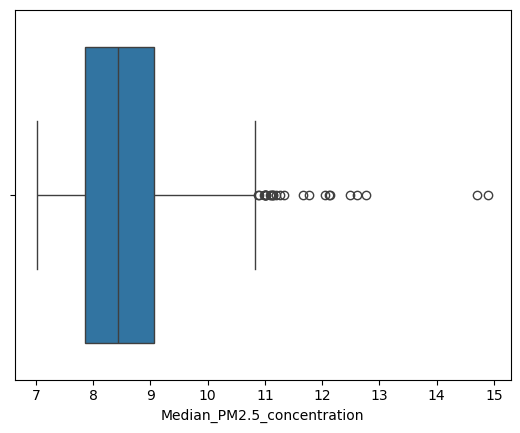

In [19]:
# Median PM 2.5 concentrations are right-skewed
sns.boxplot(data=median_conc_per_grid_square, x="Median_PM2.5_concentration")
plt.show()

## Categorise each grid square relative to the WHO 2021 interim targets and air quality guideline (AQG)

In [57]:
def WHO_guideline_categoriser(conc):
    """
    This function categorises whether an annual average 
    PM 2.5 concentration meets the four interim targets or 
    the air quality guideline (AQG) level set by the World 
    Health Organisation in 2021.

    Parameters:

    conc (float): Annual average PM 2.5 concentration in micrograms per cubic metre.

    Returns:

    out (str): String indicating which PM 2.5 annual average concentration target has been met. 
    
    """
    if conc < 5:
        out = "AQG guideline (5 micrograms per cubic metre)"
    elif 5 <= conc < 10:
        out = "Interim target 4 (10 micrograms per cubic metre)."
    elif 10 <= conc < 15:
        out = "Interim target 3 (15 micrograms per cubic metre)."
    elif 15 <= conc < 25:
        out = "Interim target 2 (25 micrograms per cubic metre)."
    elif 25 <= conc < 35:
        out = "Interim target 1 (35 micrograms per cubic metre)."
    elif conc >= 35:
        out = "Not achieving interim targets."

    return out


In [58]:
median_conc_per_grid_square["Target"] = median_conc_per_grid_square.apply(lambda x: WHO_guideline_categoriser(x["Median_PM2.5_concentration"]), axis=1)
#median_conc_per_grid_square.head()

,1km2_ID,geometry,Borough,Median_PM2.5_concentration,Target
0,5910,"POLYGON ((511000.001 203000.001, 509999.999 20...",NonGLA,7.917515,Interim target 4 (10 micrograms per cubic metre).
1,5911,"POLYGON ((512000.003 203000.001, 511000.001 20...",NonGLA,8.525852,Interim target 4 (10 micrograms per cubic metre).
2,5912,"POLYGON ((512999.997 203000.001, 512000.003 20...",NonGLA,8.970715,Interim target 4 (10 micrograms per cubic metre).
3,5918,"POLYGON ((519000.002 203000.001, 518000 203000...",NonGLA,8.182364,Interim target 4 (10 micrograms per cubic metre).
4,5919,"POLYGON ((519999.996 203000.001, 519000.002 20...",NonGLA,7.878207,Interim target 4 (10 micrograms per cubic metre).


In [59]:
# 96% of grid squares meet interim target 4 (10 micrograms per cubic metre)
# All grid squares meet either interim target 4 (10 micrograms per cubic metre) or interim target 3 (15 micrograms per cubic metre)
median_conc_per_grid_square.groupby("Target").count()

,1km2_ID,geometry,Borough,Median_PM2.5_concentration
Target,,,,
Interim target 3 (15 micrograms per cubic metre).,150,150,150,150
Interim target 4 (10 micrograms per cubic metre).,3266,3266,3266,3266


## Visualise the median PM 2.5 concentrations on an interactive choropleth map

* Note: some grid squares contain more than one polygon. The colour of the grid square is based on the polygon with the highest median concentration of PM 2.5 within the square (even if that polygon constitutes a very small portion of the square). Examples include LAEI grid IDs 8173 (Waltham Forest), 8693 (Redbrige) and 9362 (Hammersmith & Fulham).
* Outer London boroughs and non-GLA areas are closest to achieving the air quality guideline (5 micrograms/cubic metre). However, they are typically the most affluent parts of London. It would be more socially equitable to target air quality improvement activities at more deprived London boroughs (e.g. Tower Hamlets, Newham).

In [69]:
london_centre = [51.51, -0.12]

style_function = lambda x: {'fillColor': '#ffffff', 
                            'color':'#000000', 
                            'fillOpacity': 0.1, 
                            'weight': 0.1}
highlight_function = lambda x: {'fillColor': '#000000', 
                                'color':'#000000', 
                                'fillOpacity': 0.50, 
                                'weight': 0.1}

m = folium.Map(location=london_centre, zoom_start=9)

folium.Choropleth(
    geo_data=median_conc_per_grid_square,
    name="Median PM 2.5 concentrations",
    data=median_conc_per_grid_square,
    columns=["1km2_ID", "Median_PM2.5_concentration"],
    key_on="feature.properties.1km2_ID",
    fill_color="plasma",
    legend_name="PM 2.5 concentration (micrograms/cubic metre)").add_to(m)

folium.LayerControl().add_to(m)

tooltip = folium.features.GeoJson(median_conc_per_grid_square,
                                  style_function=style_function, 
                                  control=False,
                                  highlight_function=highlight_function, 
                                  tooltip=folium.features.GeoJsonTooltip(
                                      fields=["Borough", "1km2_ID", "Median_PM2.5_concentration", "Target"],
                                      style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;") 
                                  )
                                 )
m.add_child(tooltip)

m